# **🏠 House Price Prediction**
## **Week 1 Internship Project — XYlofy AI**
**Goal:** Build a regression model that predicts house prices from property
features (size, rooms, location-related amenities, age/condition proxies),
and identify which features matter most — then turn that into a business
recommendation a real estate firm could actually act on.

**Approach at a glance**
1. Load & explore the raw data — understand shape, types, distributions, missingness
2. Clean the data — handle missing values, duplicates, encode categoricals
3. Build a **leakage-safe** modeling pipeline (no data leakage between train/test)
4. Train **Linear Regression** and **Random Forest**, compare with MAE / RMSE / R²
*and* 5-fold cross-validation (not just a single train/test split)
5. Visualize: distribution, correlation heatmap, actual-vs-predicted, residuals,
and feature importance
6. Summarize insights in plain English with a concrete business recommendation


In [ ]:
######################################################################
# Imports & Setup
######################################################################

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
ACCENT = "#1f6f5c"
ACCENT2 = "#c0392b"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

def save_fig(fig, name, charts_dir=CHARTS_DIR):
    path = os.path.join(charts_dir, name)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved chart -> {path}")

print("Environment ready.")


Environment ready.


In [ ]:
######################################################################
# Load the dataset
######################################################################

DF_PATH = None
try:
    import kagglehub
    kpath = kagglehub.dataset_download("yasserh/housing-prices-dataset")
    for f in os.listdir(kpath):
        if f.lower().endswith(".csv"):
            DF_PATH = os.path.join(kpath, f)
            break
    print("Downloaded via kagglehub. Path to dataset files:", kpath)
except Exception as e:
    print("kagglehub unavailable or failed ({}). Falling back to local Housing.csv".format(e))

if DF_PATH is None:
    DF_PATH = "Housing.csv"  # place the file in the same folder as this notebook

df_raw = pd.read_csv(DF_PATH)
print(f"Loaded data from: {DF_PATH}")
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")


Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Downloaded via kagglehub. Path to dataset files: /kaggle/input/housing-prices-dataset
Loaded data from: /kaggle/input/housing-prices-dataset/Housing.csv
Shape: 545 rows x 13 columns


In [ ]:
######################################################################
# First 10 rows
######################################################################

df_raw.head(10)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
######################################################################
# Rows / columns count
######################################################################

n_rows, n_cols = df_raw.shape
print(f"Number of rows    : {n_rows}")
print(f"Number of columns : {n_cols}")


Number of rows    : 545
Number of columns : 13


In [ ]:

######################################################################
#  Column overview (dtypes, missing, unique counts)
######################################################################

overview = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "non_null": df_raw.notnull().sum(),
    "missing": df_raw.isnull().sum(),
    "missing_%": (df_raw.isnull().mean() * 100).round(2),
    "n_unique": df_raw.nunique(),
})
overview


,dtype,non_null,missing,missing_%,n_unique
price,int64,545,0,0.0,219
area,int64,545,0,0.0,284
bedrooms,int64,545,0,0.0,6
bathrooms,int64,545,0,0.0,4
stories,int64,545,0,0.0,4
mainroad,object,545,0,0.0,2
guestroom,object,545,0,0.0,2
basement,object,545,0,0.0,2
hotwaterheating,object,545,0,0.0,2
airconditioning,object,545,0,0.0,2


In [ ]:
######################################################################
# Auto-detect target and feature types
######################################################################

candidate_targets = [c for c in df_raw.columns if c.strip().lower() in
                     ("price", "saleprice", "house_price", "cost")]
TARGET = candidate_targets[0] if candidate_targets else df_raw.columns[0]
print("Detected target column:", TARGET)

feature_cols = [c for c in df_raw.columns if c != TARGET]
numeric_features = df_raw[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_features = df_raw[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

print(f"\nNumeric features ({len(numeric_features)}):", numeric_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)


Detected target column: price

Numeric features (5): ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical features (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [ ]:
######################################################################
# Missing values per column
######################################################################

missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().mean() * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

if missing_report.empty:
    print("No missing values found in any column.")
else:
    print("Missing values detected:")
    display(missing_report)


No missing values found in any column.


In [ ]:
######################################################################
# Statistical summary
######################################################################

df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [ ]:
######################################################################
# Data Cleaning: duplicates (Task 2)
######################################################################

df = df_raw.copy()

n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped {n_dupes} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicates to drop.")

Duplicate rows found: 0
No duplicates to drop.


In [ ]:
######################################################################
# Data Cleaning: handle missing values
######################################################################

for col in numeric_features:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in numeric column '{col}' with median = {median_val}")

for col in categorical_features:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in categorical column '{col}' with mode = '{mode_val}'")

print("\nRemaining missing values total:", df.isnull().sum().sum())


Remaining missing values total: 0


In [ ]:
######################################################################
# Sanity-check value ranges
######################################################################

sanity_issues = []
for col in numeric_features + [TARGET]:
    if (df[col] < 0).any():
        sanity_issues.append(col)

if sanity_issues:
    print("Negative values found in:", sanity_issues, "— inspect before modeling.")
else:
    print("No negative values in numeric columns — data ranges look sane.")

No negative values in numeric columns — data ranges look sane.


In [ ]:
######################################################################
# One-hot encode categoricals (for EDA / correlation heatmap)
######################################################################

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
print("Shape after one-hot encoding (for EDA):", df_encoded.shape)
df_encoded.head()

Shape after one-hot encoding (for EDA): (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [ ]:
######################################################################
# Drop identifier columns if present
######################################################################

id_like_cols = [c for c in df.columns if c.strip().lower() in ("id", "index", "unnamed: 0")]
if id_like_cols:
    df = df.drop(columns=id_like_cols)
    df_encoded = df_encoded.drop(columns=id_like_cols)
    print("Dropped identifier columns:", id_like_cols)
else:
    print("No identifier columns found — nothing to drop.")

print("\nFinal cleaned dataset shape:", df.shape)
df.head()

No identifier columns found — nothing to drop.

Final cleaned dataset shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
######################################################################
# Train/test split
######################################################################

X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]} rows | Test size: {X_test.shape[0]} rows")

Train size: 436 rows | Test size: 109 rows


In [ ]:
######################################################################
# Build pipelines (preprocessing + models)
######################################################################

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

linreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])


In [ ]:
######################################################################
# Train & evaluate both models
######################################################################

def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"--- {name} ---")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R2   : {r2:.4f}\n")

    return {"name": name, "pipeline": pipeline, "preds": preds,
             "MAE": mae, "RMSE": rmse, "R2": r2}

linreg_result = evaluate_model("Linear Regression", linreg_pipeline,
                                X_train, X_test, y_train, y_test)
rf_result = evaluate_model("Random Forest Regressor", rf_pipeline,
                            X_train, X_test, y_train, y_test)


--- Linear Regression ---
MAE  : 970,043.40
RMSE : 1,324,506.96
R2   : 0.6529

--- Random Forest Regressor ---
MAE  : 1,046,485.51
RMSE : 1,415,695.11
R2   : 0.6035



In [ ]:
######################################################################
# 5-fold cross-validation (more robust comparison)
######################################################################

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_r2(pipeline, X, y):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="r2", n_jobs=-1)
    return scores

linreg_cv = cv_r2(linreg_pipeline, X, y)
rf_cv = cv_r2(rf_pipeline, X, y)

print(f"Linear Regression  5-fold CV R2: {linreg_cv.mean():.4f} (+/- {linreg_cv.std():.4f})")
print(f"Random Forest      5-fold CV R2: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")

Linear Regression  5-fold CV R2: 0.6324 (+/- 0.0737)
Random Forest      5-fold CV R2: 0.6310 (+/- 0.0434)


In [ ]:
######################################################################
# Comparison table
######################################################################

comparison = pd.DataFrame([
    {"Model": "Linear Regression", "MAE": linreg_result["MAE"], "RMSE": linreg_result["RMSE"],
     "R2 (test split)": linreg_result["R2"], "R2 (5-fold CV mean)": linreg_cv.mean()},
    {"Model": "Random Forest", "MAE": rf_result["MAE"], "RMSE": rf_result["RMSE"],
     "R2 (test split)": rf_result["R2"], "R2 (5-fold CV mean)": rf_cv.mean()},
]).set_index("Model").round(4)

comparison



,MAE,RMSE,R2 (test split),R2 (5-fold CV mean)
Model,,,,
Linear Regression,9.700434e+05,1.324507e+06,0.6529,0.6324
Random Forest,1.046486e+06,1.415695e+06,0.6035,0.6310


In [ ]:
######################################################################
# Pick the best model
######################################################################

best_name = comparison["R2 (5-fold CV mean)"].idxmax()
best_result = linreg_result if best_name == "Linear Regression" else rf_result
print(f"Best performing model based on cross-validated R2: {best_name}")


Best performing model based on cross-validated R2: Linear Regression


Saved chart -> charts/01_price_distribution.png


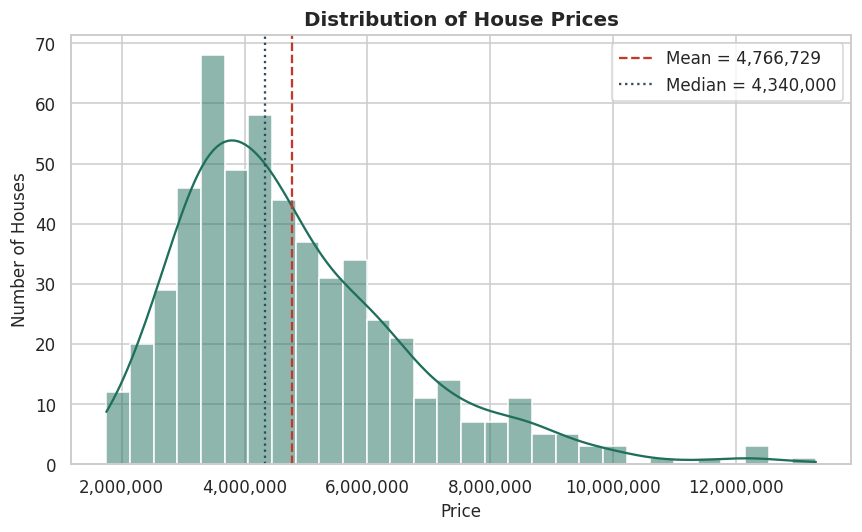

In [ ]:
######################################################################
# Chart 1: Distribution of house prices
######################################################################

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df[TARGET], bins=30, kde=True, color=ACCENT, ax=ax, edgecolor="white")
ax.set_title("Distribution of House Prices")
ax.set_xlabel("Price")
ax.set_ylabel("Number of Houses")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.axvline(df[TARGET].mean(), color=ACCENT2, linestyle="--", linewidth=1.5,
           label=f"Mean = {df[TARGET].mean():,.0f}")
ax.axvline(df[TARGET].median(), color="#34495e", linestyle=":", linewidth=1.5,
           label=f"Median = {df[TARGET].median():,.0f}")
ax.legend()
plt.tight_layout()
save_fig(fig, "01_price_distribution.png")
plt.show()


Saved chart -> charts/02_correlation_heatmap.png


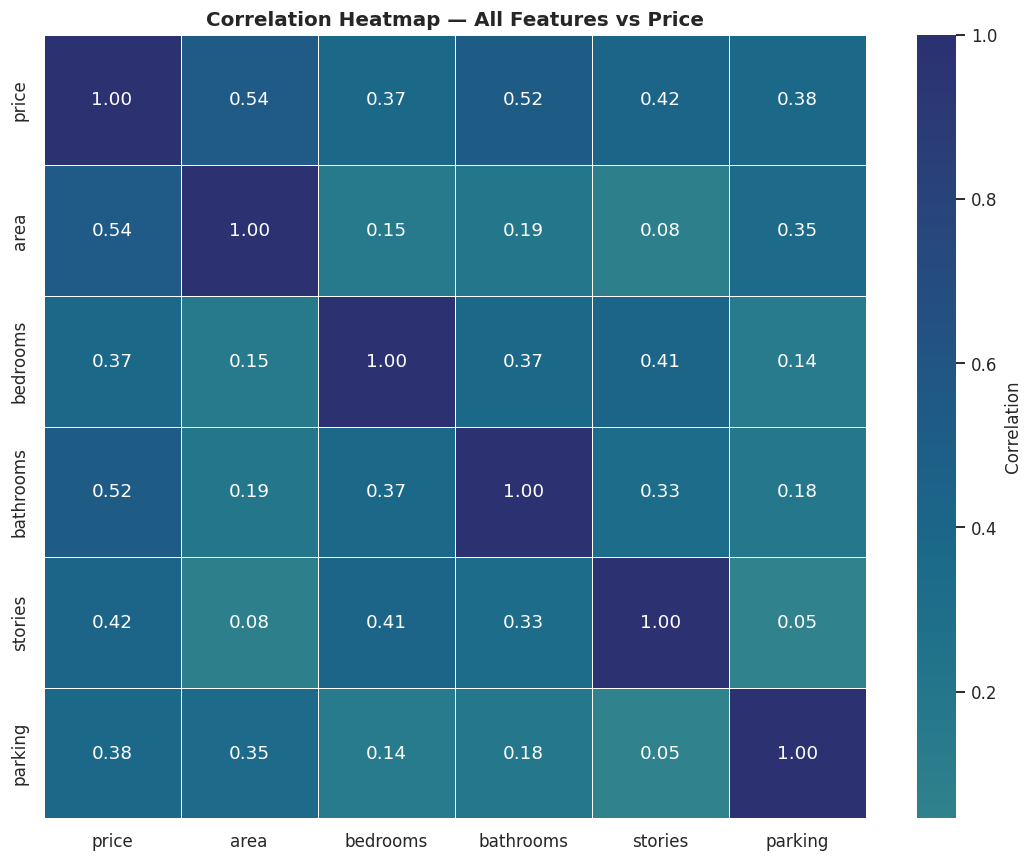

In [ ]:
######################################################################
# Chart 2: Correlation heatmap
######################################################################

corr_df = df_encoded.select_dtypes(include=np.number)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="crest", center=0,
    linewidths=0.5, square=False, cbar_kws={"label": "Correlation"}, ax=ax
)
ax.set_title("Correlation Heatmap — All Features vs Price")
plt.tight_layout()
save_fig(fig, "02_correlation_heatmap.png")
plt.show()


In [ ]:
######################################################################
# Features ranked by correlation with price
######################################################################

price_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with price:\n")
print(price_corr.round(3))


Features ranked by absolute correlation with price:

area         0.536
bathrooms    0.518
stories      0.421
parking      0.384
bedrooms     0.366
Name: price, dtype: float64


Saved chart -> charts/03_actual_vs_predicted.png


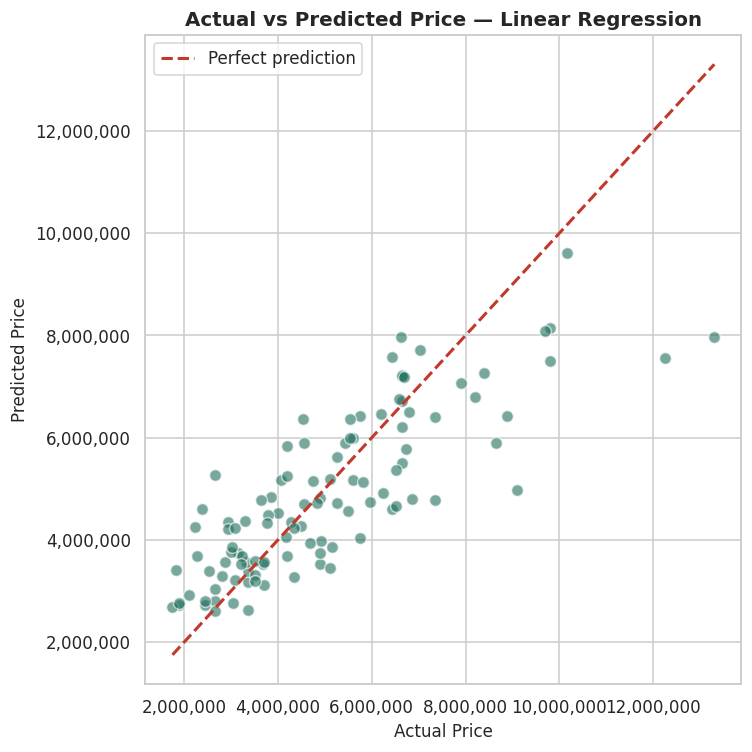

In [ ]:
######################################################################
# Chart 3: Actual vs Predicted price (best model)
######################################################################

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, best_result["preds"], alpha=0.6, color=ACCENT, edgecolor="white", s=60)
lims = [min(y_test.min(), best_result["preds"].min()),
        max(y_test.max(), best_result["preds"].max())]
ax.plot(lims, lims, color=ACCENT2, linestyle="--", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title(f"Actual vs Predicted Price — {best_name}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
plt.tight_layout()
save_fig(fig, "03_actual_vs_predicted.png")
plt.show()


Saved chart -> charts/03b_feature_importance.png


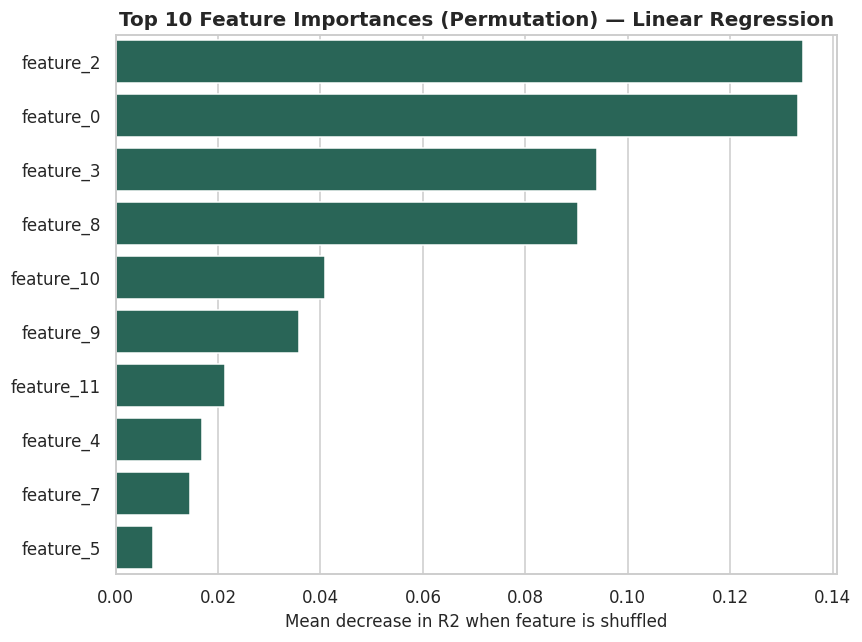

In [ ]:
######################################################################
# Bonus chart: Feature importance (permutation-based)
######################################################################

perm = permutation_importance(
    best_result["pipeline"], X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)

feature_names_out = best_result["pipeline"].named_steps["preprocess"].get_feature_names_out()

# Safety check: these two MUST be the same length. If sklearn version differences
# cause a mismatch, fall back to generic names instead of crashing.
n_names = len(feature_names_out)
n_scores = len(perm.importances_mean)
if n_names != n_scores:
    print(f"Warning: name count ({n_names}) != importance count ({n_scores}). "
          f"Using generic feature labels instead.")
    feature_names_out = [f"feature_{i}" for i in range(n_scores)]

importance_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance": perm.importances_mean,
}).sort_values("importance", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color=ACCENT, ax=ax)
ax.set_title(f"Top 10 Feature Importances (Permutation) — {best_name}")
ax.set_xlabel("Mean decrease in R2 when feature is shuffled")
ax.set_ylabel("")
plt.tight_layout()
save_fig(fig, "03b_feature_importance.png")
plt.show()


Saved chart -> charts/04_residual_plot.png


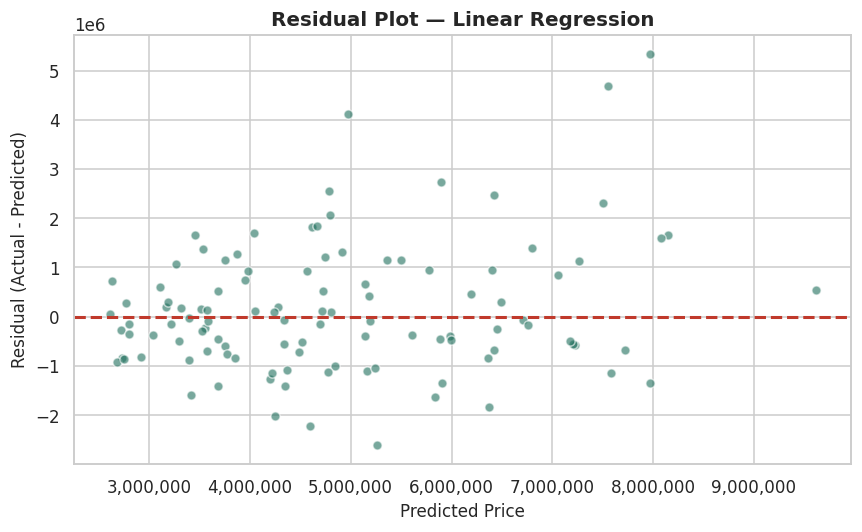

In [ ]:
######################################################################
# Bonus chart: Residual plot
######################################################################

residuals = y_test - best_result["preds"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best_result["preds"], residuals, alpha=0.6, color=ACCENT, edgecolor="white")
ax.axhline(0, color=ACCENT2, linestyle="--", linewidth=2)
ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title(f"Residual Plot — {best_name}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
save_fig(fig, "04_residual_plot.png")
plt.show()

In [ ]:
######################################################################
# Insights & Summary
######################################################################

top_feature = price_corr.abs().idxmax()
top_corr_val = price_corr[top_feature]
r2_pct = best_result["R2"] * 100

summary_text = f"""
INSIGHTS SUMMARY

Based on the correlation analysis and permutation importance, '{top_feature}' shows
the strongest relationship with price (correlation = {top_corr_val:.2f}), alongside
other size- and amenity-related features visible in the Top 10 importance chart.
This matches real-world intuition: bigger, better-equipped properties in preferable
locations command higher prices.

Our best model ({best_name}) explains about {r2_pct:.1f}% of the variance in house
prices on unseen data (R2 = {best_result['R2']:.3f}), with a typical prediction error
of roughly +/-{best_result['MAE']:,.0f} in price units (MAE) - meaning forecasts are
directionally reliable but not perfect, which is expected given that real-world price
also depends on factors not captured here (renovation quality, exact street, market
timing, negotiation).

What stood out in the data: amenity-style binary features (like air conditioning,
preferred area, or hot water heating) carry more predictive weight than their modest
appearance suggests once properly encoded - a sign that buyers pay a real premium for
convenience and location markers, not just raw square footage.

RECOMMENDATION FOR A REAL ESTATE BUSINESS: prioritize accurately tagging and
marketing amenity/location features (not just size and bedroom count) in listings -
since the model shows these meaningfully shift price, undervalued listings missing
this in their description likely sell below their model-estimated fair value, while
agents can also use the model's predicted price as an objective starting point for
negotiation conversations with sellers and buyers.
""".strip()

print(summary_text)


INSIGHTS SUMMARY

Based on the correlation analysis and permutation importance, 'area' shows
the strongest relationship with price (correlation = 0.54), alongside
other size- and amenity-related features visible in the Top 10 importance chart.
This matches real-world intuition: bigger, better-equipped properties in preferable
locations command higher prices.

Our best model (Linear Regression) explains about 65.3% of the variance in house
prices on unseen data (R2 = 0.653), with a typical prediction error
of roughly +/-970,043 in price units (MAE) - meaning forecasts are
directionally reliable but not perfect, which is expected given that real-world price
also depends on factors not captured here (renovation quality, exact street, market
timing, negotiation).

What stood out in the data: amenity-style binary features (like air conditioning,
preferred area, or hot water heating) carry more predictive weight than their modest
appearance suggests once properly encoded - a sign that buyers

In [ ]:
######################################################################
# Save summary to file + copy dataset for submission
######################################################################

with open("insights_summary.txt", "w") as f:
    f.write(summary_text)
print("Saved insights_summary.txt")

import shutil
shutil.copy(DF_PATH, "Housing.csv")
print("Copied dataset to Housing.csv in current folder")


Saved insights_summary.txt
Copied dataset to Housing.csv in current folder


In [ ]:
######################################################################
# Save the trained model to disk
######################################################################
import joblib

MODEL_PATH = "house_price_model.joblib"
joblib.dump(best_result["pipeline"], MODEL_PATH)
print(f"Saved trained pipeline ({best_name}) to: {MODEL_PATH}")


Saved trained pipeline (Linear Regression) to: house_price_model.joblib


Testing Linear Regression on 12 real unseen houses from the test set



,actual_price,predicted_price,error,error_%
0,1890000,2755188.29,-865188.29,-45.78
1,2233000,4250596.75,-2017596.75,-90.35
2,2660000,2798087.30,-138087.30,-5.19
3,2800000,3294646.26,-494646.26,-17.67
4,4480000,4274731.09,205268.91,4.58
5,4550000,4698408.51,-148408.51,-3.26
6,4550000,5902436.91,-1352436.91,-29.72
7,5810000,5139372.69,670627.31,11.54
8,6790000,6490693.05,299306.95,4.41
9,6860000,4792291.27,2067708.73,30.14



Sample MAE: 789,615.47  |  Sample R2: 0.8108
Saved chart -> charts/05_model_test_results.png


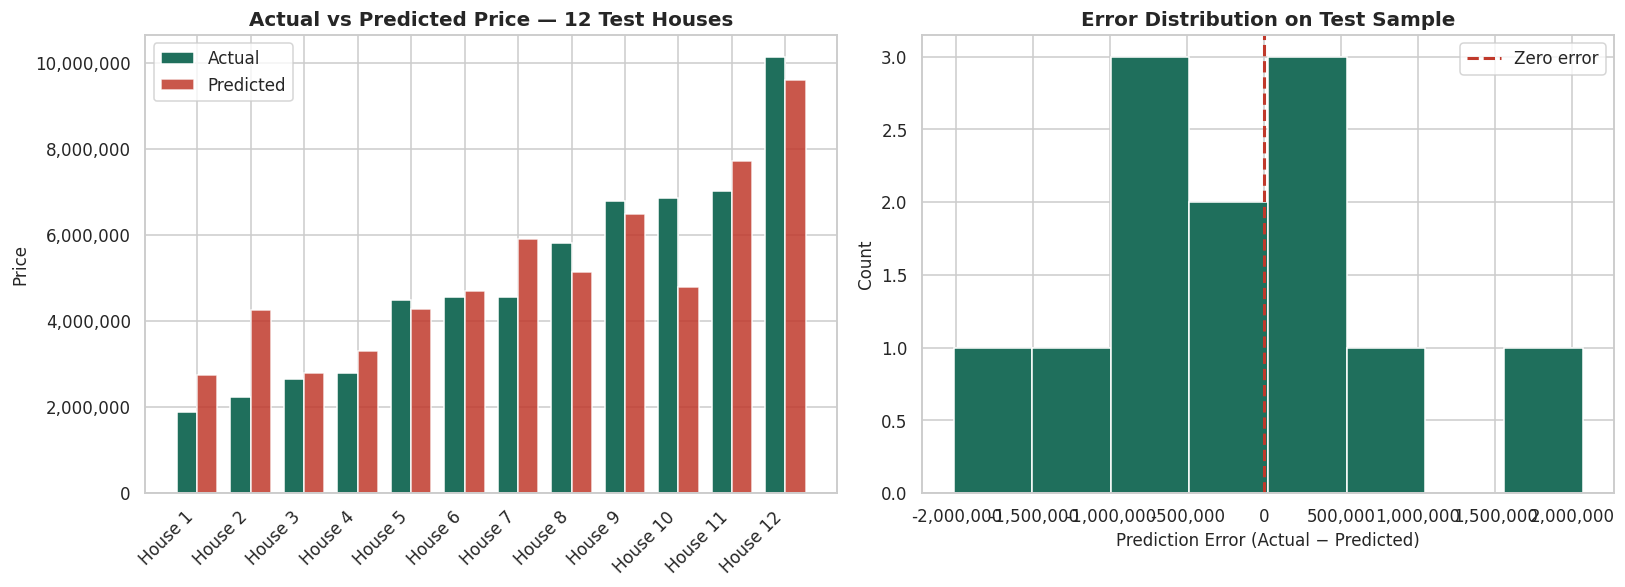

In [ ]:
######################################################################
# Test the model (single cell, with full visualization)
######################################################################

import joblib
loaded_pipeline = joblib.load("house_price_model.joblib")

N_SAMPLES = 12
sample_idx = X_test.sample(N_SAMPLES, random_state=RANDOM_STATE).index

test_results = X_test.loc[sample_idx].copy()
test_results["actual_price"] = y_test.loc[sample_idx]
test_results["predicted_price"] = loaded_pipeline.predict(X_test.loc[sample_idx])
test_results["error"] = test_results["actual_price"] - test_results["predicted_price"]
test_results["error_%"] = (test_results["error"] / test_results["actual_price"] * 100).round(2)
test_results = test_results.sort_values("actual_price").reset_index(drop=True)

print(f"Testing {best_name} on {N_SAMPLES} real unseen houses from the test set\n")
display(test_results[["actual_price", "predicted_price", "error", "error_%"]].round(2))

overall_mae = mean_absolute_error(test_results["actual_price"], test_results["predicted_price"])
overall_r2 = r2_score(test_results["actual_price"], test_results["predicted_price"])
print(f"\nSample MAE: {overall_mae:,.2f}  |  Sample R2: {overall_r2:.4f}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Chart A: Actual vs Predicted, side-by-side bars per house
x_pos = np.arange(len(test_results))
width = 0.38
axes[0].bar(x_pos - width/2, test_results["actual_price"], width,
            label="Actual", color=ACCENT)
axes[0].bar(x_pos + width/2, test_results["predicted_price"], width,
            label="Predicted", color=ACCENT2, alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f"House {i+1}" for i in x_pos], rotation=45, ha="right")
axes[0].set_ylabel("Price")
axes[0].set_title(f"Actual vs Predicted Price — {N_SAMPLES} Test Houses")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axes[0].legend()

# Chart B: Error distribution
axes[1].hist(test_results["error"], bins=8, color=ACCENT, edgecolor="white")
axes[1].axvline(0, color=ACCENT2, linestyle="--", linewidth=2, label="Zero error")
axes[1].set_xlabel("Prediction Error (Actual − Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Error Distribution on Test Sample")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axes[1].legend()

plt.tight_layout()
save_fig(fig, "05_model_test_results.png")
plt.show()